# Transformer — Shape Tests
Verify that every component produces the correct output shape using random tensors.

In [1]:
import sys
sys.path.insert(0, '..')  # make root importable

import torch
import math

## Config

In [2]:
B   = 2       # batch size
T   = 16      # source sequence length
T2  = 12      # target sequence length
D   = 64      # d_model (small for testing)
H   = 4       # n_heads
D_K = D // H  # d_k per head
D_FF = 256    # feed-forward hidden dim (4 * D)

print(f'B={B}, T={T}, T2={T2}, D={D}, H={H}, D_K={D_K}, D_FF={D_FF}')

B=2, T=16, T2=12, D=64, H=4, D_K=16, D_FF=256


---
## 1. Activations
Expected: same shape as input

In [3]:
from transformer.activations import ReLU, GELU

x = torch.randn(B, T, D)

relu = ReLU()
gelu = GELU()

print('Input shape:     ', x.shape)
print('ReLU output:     ', relu(x).shape,  '  ✅' if relu(x).shape == x.shape else '  ❌')
print('GELU output:     ', gelu(x).shape,  '  ✅' if gelu(x).shape == x.shape else '  ❌')

# Sanity: ReLU has no negatives
assert (relu(x) >= 0).all(), 'ReLU produced negative values!'
print('ReLU >= 0:        ✅')

Input shape:      torch.Size([2, 16, 64])
ReLU output:      torch.Size([2, 16, 64])   ✅
GELU output:      torch.Size([2, 16, 64])   ✅
ReLU >= 0:        ✅


---
## 2. LayerNorm
Expected: `(..., D) → (..., D)`, mean≈0, std≈1 per token

In [4]:
from transformer.normalization import LayerNorm

ln = LayerNorm(D)
x = torch.randn(B, T, D)
out = ln(x)

print('Input shape:     ', x.shape)
print('Output shape:    ', out.shape, '  ✅' if out.shape == x.shape else '  ❌')
print(f'Mean (≈0):        {out.mean().item():.6f}')
print(f'Std  (≈1):        {out.std().item():.6f}')

Input shape:      torch.Size([2, 16, 64])
Output shape:     torch.Size([2, 16, 64])   ✅
Mean (≈0):        -0.000000
Std  (≈1):        1.000244


---
## 3. Scaled Dot-Product Attention
Expected: `(B, T, D_K) → (B, T, D_K)`

In [5]:
from attention.scaled_dot_product import ScaledDotProductAttention

sdpa = ScaledDotProductAttention()
Q = torch.randn(B, T, D_K)
K = torch.randn(B, T, D_K)
V = torch.randn(B, T, D_K)

out = sdpa(Q, K, V)
print('Q/K/V shape:     ', Q.shape)
print('Output shape:    ', out.shape, '  ✅' if out.shape == (B, T, D_K) else '  ❌')

# With causal mask
mask = torch.triu(torch.ones(T, T, dtype=torch.bool), diagonal=1)
out_masked = sdpa(Q, K, V, mask=mask)
print('Output (masked): ', out_masked.shape, '  ✅' if out_masked.shape == (B, T, D_K) else '  ❌')

Q/K/V shape:      torch.Size([2, 16, 16])
Output shape:     torch.Size([2, 16, 16])   ✅
Output (masked):  torch.Size([2, 16, 16])   ✅


---
## 4. Multi-Head Attention
Expected: `(B, T, D) → (B, T, D)`

In [6]:
from attention.multi_head import MultiHeadAttention

mha = MultiHeadAttention(D, H)
x = torch.randn(B, T, D)

# Self-attention: Q=K=V=x
out = mha(x, x, x)
print('Input shape:     ', x.shape)
print('Output shape:    ', out.shape, '  ✅' if out.shape == (B, T, D) else '  ❌')

# Cross-attention: Q from decoder (T2), K/V from encoder (T)
q = torch.randn(B, T2, D)
kv = torch.randn(B, T, D)
out_cross = mha(q, kv, kv)
print('Cross-attn out:  ', out_cross.shape, '  ✅' if out_cross.shape == (B, T2, D) else '  ❌')

Input shape:      torch.Size([2, 16, 64])
Output shape:     torch.Size([2, 16, 64])   ✅
Cross-attn out:   torch.Size([2, 12, 64])   ✅


---
## 5. Position-wise Feed-Forward
Expected: `(B, T, D) → (B, T, D)`

In [7]:
from transformer.feed_forward import PositionWiseFeedForward

ffn = PositionWiseFeedForward(D, D_FF)
x = torch.randn(B, T, D)
out = ffn(x)

print('Input shape:     ', x.shape)
print('Output shape:    ', out.shape, '  ✅' if out.shape == (B, T, D) else '  ❌')

Input shape:      torch.Size([2, 16, 64])
Output shape:     torch.Size([2, 16, 64])   ✅


---
## 6. Sinusoidal Positional Encoding
Expected: `(B, T, D) → (B, T, D)`

In [8]:
from positional_encoding.sinusoidal import SinusoidalPositionalEncoding

pe = SinusoidalPositionalEncoding(d_model=D, max_seq_len=512)
x = torch.randn(B, T, D)
out = pe(x)

print('Input shape:     ', x.shape)
print('Output shape:    ', out.shape, '  ✅' if out.shape == (B, T, D) else '  ❌')
print('PE buffer shape: ', pe.pe.shape)  # should be (1, 512, D)

Input shape:      torch.Size([2, 16, 64])
Output shape:     torch.Size([2, 16, 64])   ✅
PE buffer shape:  torch.Size([1, 512, 64])


---
## 7. Transformer Embedding
Expected: `(B, T) token IDs → (B, T, D)`

In [9]:
from transformer.embedding import TransformerEmbedding

VOCAB = 1000
emb = TransformerEmbedding(vocab_size=VOCAB, d_model=D)
tokens = torch.randint(0, VOCAB, (B, T))
out = emb(tokens)

print('Token IDs shape: ', tokens.shape)
print('Output shape:    ', out.shape, '  ✅' if out.shape == (B, T, D) else '  ❌')

Token IDs shape:  torch.Size([2, 16])
Output shape:     torch.Size([2, 16, 64])   ✅


---
## 8. Full Transformer
Expected: `(B, T2, tgt_vocab_size)` logits

In [10]:
from transformer.model import Transformer
from transformer.config import TransformerConfig

cfg = TransformerConfig(
    src_vocab_size=1000,
    tgt_vocab_size=1000,
    d_model=D,
    n_heads=H,
    d_ff=D_FF,
    n_encoder_layers=2,
    n_decoder_layers=2,
    max_seq_len=512,
)

model = Transformer(cfg)
PAD_ID = 0

src = torch.randint(1, 1000, (B, T))    # source tokens (no PAD)
tgt = torch.randint(1, 1000, (B, T2))   # target tokens (no PAD)

# Add some PAD tokens to src for mask testing
src[0, -3:] = PAD_ID

src_mask = Transformer.generate_padding_mask(src, pad_id=PAD_ID)  # (B, 1, 1, T)
tgt_mask = Transformer.generate_causal_mask(T2)                   # (T2, T2)

print('src shape:       ', src.shape)
print('tgt shape:       ', tgt.shape)
print('src_mask shape:  ', src_mask.shape)
print('tgt_mask shape:  ', tgt_mask.shape)
print()

logits = model(src, tgt, src_mask, tgt_mask)
expected = (B, T2, cfg.tgt_vocab_size)
print('Logits shape:    ', logits.shape, '  ✅' if logits.shape == expected else '  ❌')
print('Expected:        ', expected)

src shape:        torch.Size([2, 16])
tgt shape:        torch.Size([2, 12])
src_mask shape:   torch.Size([2, 1, 1, 16])
tgt_mask shape:   torch.Size([12, 12])

Logits shape:     torch.Size([2, 12, 1000])   ✅
Expected:         (2, 12, 1000)


---
## 9. Mask Visualisation
Quick look at what the masks actually look like.

In [14]:
print('Causal mask (T=6):')
print(Transformer.generate_causal_mask(6).int())

print()
tokens_with_pad = torch.tensor([[3, 5, 1, 0, 0], [2, 4, 0, 0, 0]])
print('Padding mask:')
print(Transformer.generate_padding_mask(tokens_with_pad, pad_id=0).squeeze().int())

Causal mask (T=6):
tensor([[0, 1, 1, 1, 1, 1],
        [0, 0, 1, 1, 1, 1],
        [0, 0, 0, 1, 1, 1],
        [0, 0, 0, 0, 1, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 0]], dtype=torch.int32)

Padding mask:
tensor([[0, 0, 0, 1, 1],
        [0, 0, 1, 1, 1]], dtype=torch.int32)


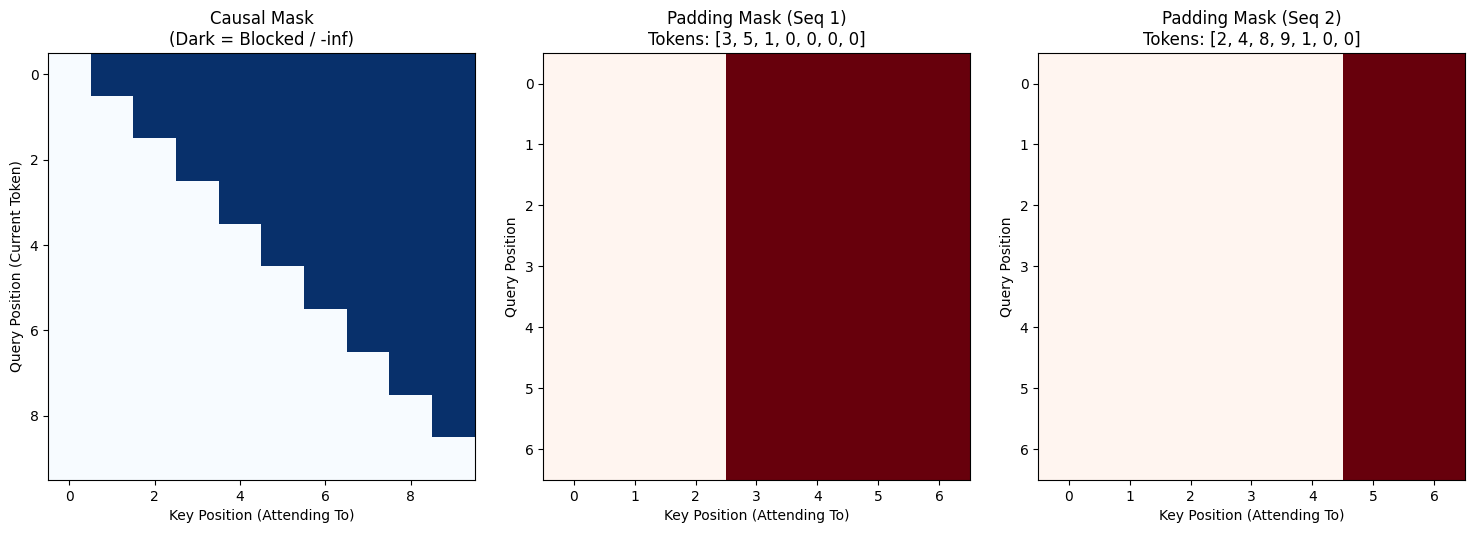

In [11]:
import matplotlib.pyplot as plt

# Generate masks
causal_mask = Transformer.generate_causal_mask(10)
tokens_with_pad = torch.tensor([[3, 5, 1, 0, 0, 0, 0], [2, 4, 8, 9, 1, 0, 0]])
pad_mask = Transformer.generate_padding_mask(tokens_with_pad, pad_id=0).squeeze()

# Setup plotting
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
seq_len = tokens_with_pad.shape[1]

# 1. Causal Mask
axs[0].imshow(causal_mask, cmap='Blues')
axs[0].set_title('Causal Mask\n(Dark = Blocked / -inf)')
axs[0].set_xlabel('Key Position (Attending To)')
axs[0].set_ylabel('Query Position (Current Token)')

# 2. Padding Mask (Seq 1)
# Expand the 1D pad mask to 2D so we can see how it broadcasts across queries
broadcasted_pad_1 = pad_mask[0].expand(seq_len, seq_len)
axs[1].imshow(broadcasted_pad_1, cmap='Reds')
axs[1].set_title(f'Padding Mask (Seq 1)\nTokens: {tokens_with_pad[0].tolist()}')
axs[1].set_xlabel('Key Position (Attending To)')
axs[1].set_ylabel('Query Position')

# 3. Padding Mask (Seq 2)
broadcasted_pad_2 = pad_mask[1].expand(seq_len, seq_len)
axs[2].imshow(broadcasted_pad_2, cmap='Reds')
axs[2].set_title(f'Padding Mask (Seq 2)\nTokens: {tokens_with_pad[1].tolist()}')
axs[2].set_xlabel('Key Position (Attending To)')
axs[2].set_ylabel('Query Position')

plt.tight_layout()
plt.show()
